# Analyse Statistique - Réseaux d'Acteurs IA

Ce carnet s'inscrit dans une approche en boule de neige, semi-manuelle: nous partons d'un noyau d'entreprises connues, puis chaque fiche enrichie ouvre vers de nouveaux acteurs, de nouvelles alliances et de nouvelles sources a verifier.

## Approche methodologique (semi-manuelle)

1. Amorcage multi-sources: constitution d'un premier socle d'entreprises via des sources generalistes et financieres.
2. Enrichissement iteratif: chaque entreprise completee permet d'identifier des partenaires, investisseurs, acquisitions, puis de remonter vers d'autres fiches.
3. Verification croisee: les informations sensibles (partenariats strategiques, montants, statut) sont recoupees sur plusieurs references.
4. Deduplication continue: les variantes de noms, filiales et doublons de source sont consolides avant analyse.
5. Recherche ciblee de partenariats: des recherches focalisees (communiques, pages entreprises, fiches publiques) completent les zones non couvertes automatiquement.

## Sources exploitees (principales)

- Wikipedia: https://www.wikipedia.org/
- Wikidata: https://www.wikidata.org/
- Forbes AI 50: https://www.forbes.com/lists/ai50/
- CompaniesMarketCap (AI): https://companiesmarketcap.com/ai/
- AI Startups Europe: https://www.aistartups.co/
- Dealroom: https://dealroom.co/

## Deduplication et controle qualite

La deduplication n'est pas un nettoyage final unique, mais une boucle recurrente dans le pipeline: a chaque import ou enrichissement, on controle les collisions de noms, les variantes orthographiques, les pays et les metadonnees critiques. Cette logique est combinee a des scripts de normalisation et a une validation humaine sur les cas ambigus.

## Objectif de ce carnet

Produire une lecture statistique exploitable (pays, annee de fondation, secteurs, completude, validation) tout en rendant explicite le caractere progressif et semi-manuel de la construction de la base.

## Schema synthetique de l'approche (5 etapes)

1. Amorcage multi-sources
   - Constitution d'un socle initial d'entreprises (Wikipedia, Wikidata, Forbes AI 50, CompaniesMarketCap, AI Startups Europe, Dealroom).

2. Enrichissement en boule de neige
   - Chaque fiche enrichie revele de nouveaux acteurs, partenaires, investisseurs ou operations.

3. Deduplication et normalisation
   - Consolidation des variantes de noms, harmonisation pays/secteurs, suppression des doublons.

4. Recherche ciblee de partenariats
   - Verification manuelle assistee sur des sources ciblees (sites officiels, communiques, fiches publiques).

5. Validation et iteration
   - Arbitrage humain sur les cas ambigus, mise a jour de la base, puis nouveau cycle d'enrichissement.

```mermaid
flowchart LR
    A[Amorcage multi-sources] --> B[Enrichissement en boule de neige]
    B --> C[Deduplication et normalisation]
    C --> D[Recherche ciblee de partenariats]
    D --> E[Validation humaine]
    E --> F[Mise a jour de la base]
    F --> B
```

Flux global: Amorcage -> Boule de neige -> Deduplication -> Recherche ciblee -> Validation -> Nouveau cycle

## 1. Configuration et Chargement des Données

### Introduction de la section
Cette section prepare l'environnement d'analyse, charge les donnees via l'API paginee, puis construit un DataFrame pret pour les statistiques. L'objectif est de garantir la robustesse du chargement et la coherence des champs critiques (capitalisation, validation).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
import os
from datetime import datetime

# Configuration des graphiques
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn-darkgrid')

sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Bibliothèques importées")

✓ Bibliothèques importées


In [2]:
# Charger les données depuis l'API (pagination globale)
BASE_URL = 'http://localhost:3000/api/enterprises'

def parse_capitalization_millions(value):
    """Convertit la capitalisation format FR (ex: '1 234,56') en float (millions)."""
    if value is None:
        return 0.0
    text = str(value).strip()
    if text == '' or text == '0':
        return 0.0
    text = text.replace(' ', '').replace('\u202f', '').replace('\u00a0', '').replace(',', '.')
    try:
        return float(text)
    except ValueError:
        return 0.0

def fetch_all_enterprises():
    all_items = []
    page = 1
    limit = 100

    while True:
        params = {
            'page': page,
            'limit': limit
        }
        response = requests.get(BASE_URL, params=params, timeout=20)
        payload = response.json()

        if not response.ok:
            raise RuntimeError(payload.get('error', f'Erreur HTTP {response.status_code}'))

        items = payload.get('items', [])
        all_items.extend(items)

        pagination = payload.get('pagination', {})
        if not pagination.get('hasNextPage', False):
            break
        page += 1

    return all_items

try:
    data = fetch_all_enterprises()
    df = pd.DataFrame(data)

    if not df.empty:
        df['capitalization'] = df['capitalization'].fillna('0').astype(str)
        df['capitalization_millions'] = df['capitalization'].apply(parse_capitalization_millions)
        df['is_validated'] = pd.to_numeric(df['is_validated'], errors='coerce').fillna(0).astype(int)

    non_validees = (df['is_validated'] == 0).sum() if not df.empty else 0
    partiellement_validees = (df['is_validated'] == 1).sum() if not df.empty else 0
    validees = (df['is_validated'] == 2).sum() if not df.empty else 0

    print(f"✓ {len(df)} entreprises chargées")
    print(
        f"Validation: non={non_validees}, "
        f"partiel={partiellement_validees}, valide={validees}"
    )
    print(f"\nColonnes: {df.columns.tolist()}")
except Exception as e:
    print(f"✗ Erreur: {e}")
    df = None

✓ 1718 entreprises chargées
Validation: non=1718, partiel=0, valide=0

Colonnes: ['id', 'name', 'sector', 'country', 'founded_year', 'description', 'website', 'logo_url', 'capitalization', 'employees_count', 'created_at', 'updated_at', 'ai_products', 'financing', 'acquisitions', 'revenue_model', 'partnerships_info', 'significant_risks', 'personal_analysis', 'headquarter_city', 'main_investors', 'funds_raised', 'is_validated', 'main_competitors', 'strategic_partnerships', 'main_acquisitions', 'revenue_millions', 'key_resources', 'capitalization_millions']


In [3]:
# Afficher un aperçu des données
print("📊 Aperçu des données:\n")
preview_cols = [
    'id', 'name', 'sector', 'country', 'founded_year',
    'capitalization', 'capitalization_millions', 'is_validated'
]
preview_cols = [c for c in preview_cols if c in df.columns]
print(df[preview_cols].head(10))
print(f"\nShape: {df.shape}")
print(f"\nTypes de données:\n{df.dtypes}")

📊 Aperçu des données:

     id                           name                               sector  \
0  1752                          2CRSI                                  NaN   
1  1750                             5C                                  NaN   
2   288                     AGVOLUTION  ICT, Energy & Utilities, Operations   
3   290          AI Medical Technology            ICT, Health & Social Care   
4   291               AI Superior GmbH                                  ICT   
5   292                 AI Supervision            Manufacturing, Operations   
6   293                         AI-BOB                         Construction   
7   296                          AI-UI      Cross Industry, ICT, Operations   
8  1812  AI2 (selon sources publiques)                                  NaN   
9   102                      AI21 Labs                                  ICT   

   country  founded_year capitalization  capitalization_millions  is_validated  
0      NaN           NaN  

### Debut d'analyse
Le chargement confirme que la base est exploitable et que les colonnes attendues sont presentes. Cette verification limite les erreurs en aval et permet de documenter la qualite initiale des donnees avant interpretation.

## 2. Statistiques Générales

### Introduction de la section
Cette etape mesure la completude de chaque champ afin d'identifier les variables fiables pour l'analyse et celles qui necessitent un enrichissement prioritaire.

📈 Taux de Complétude des Champs:

id                       : 1718/1718 (100.0%)
name                     : 1718/1718 (100.0%)
sector                   : 1471/1718 ( 85.6%)
country                  : 1496/1718 ( 87.1%)
founded_year             : 101/1718 (  5.9%)
description              : 1357/1718 ( 79.0%)
website                  : 1369/1718 ( 79.7%)
logo_url                 :   1/1718 (  0.1%)
capitalization           : 134/1718 (  7.8%)
employees_count          :  14/1718 (  0.8%)
created_at               : 1718/1718 (100.0%)
updated_at               : 1718/1718 (100.0%)
ai_products              :  12/1718 (  0.7%)
financing                :   9/1718 (  0.5%)
acquisitions             :   9/1718 (  0.5%)
revenue_model            :   9/1718 (  0.5%)
partnerships_info        :   9/1718 (  0.5%)
significant_risks        :   9/1718 (  0.5%)
personal_analysis        :   9/1718 (  0.5%)
headquarter_city         :  57/1718 (  3.3%)
main_investors           :  45/1718 (  2.6%)
funds_raised 

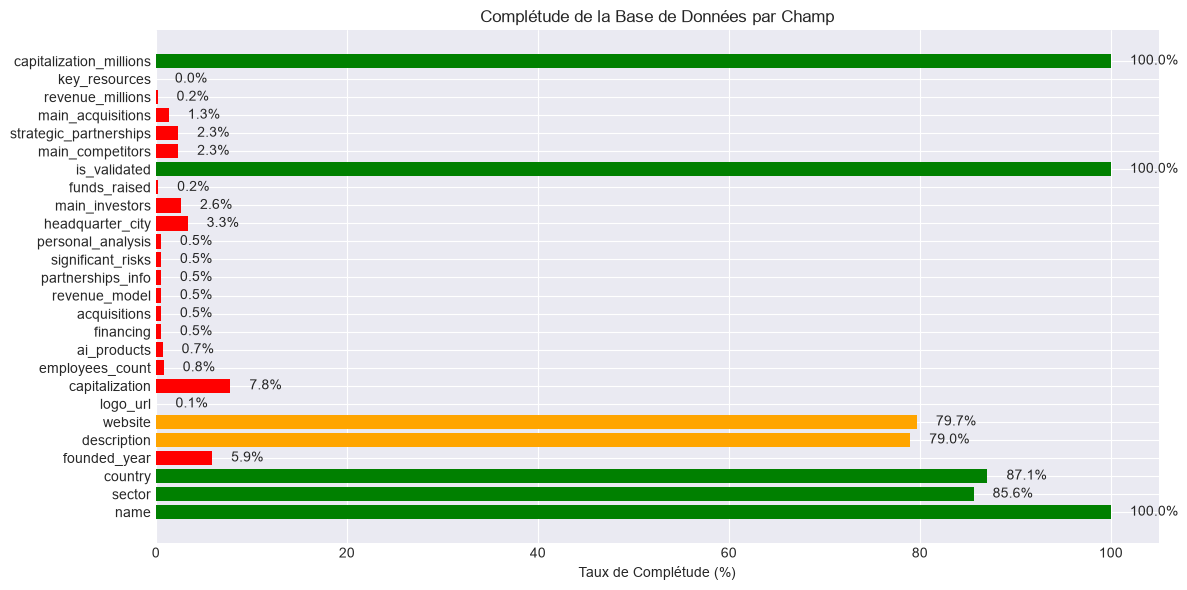

In [4]:
# Statistiques de complétude
print("📈 Taux de Complétude des Champs:\n")

def filled_series(series):
    return series.notna() & (series.astype(str).str.strip() != '')

completeness = {}
for col in df.columns:
    if col == 'capitalization':
        # Règle métier: '0' = pas d'information de capitalisation
        non_null = (df['capitalization_millions'] > 0).sum() if 'capitalization_millions' in df.columns else 0
    else:
        non_null = filled_series(df[col]).sum()
    pct = (non_null / len(df)) * 100 if len(df) else 0
    completeness[col] = pct
    print(f"{col:25s}: {non_null:3d}/{len(df)} ({pct:5.1f}%)")

# Visualiser la complétude
fig, ax = plt.subplots(figsize=(12, 6))
cols = [c for c in completeness.keys() if c not in ['id', 'created_at', 'updated_at']]
values = [completeness[c] for c in cols]

bars = ax.barh(cols, values, color=['green' if v >= 80 else 'orange' if v >= 50 else 'red' for v in values])
ax.set_xlabel('Taux de Complétude (%)')
ax.set_title('Complétude de la Base de Données par Champ')
ax.set_xlim(0, 105)

# Ajouter les pourcentages sur les barres
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(val + 2, i, f'{val:.1f}%', va='center')

plt.tight_layout()
plt.show()

### Debut d'analyse
Les taux de completude mettent en evidence un contraste entre champs descriptifs bien renseignes (nom, description, site) et champs financiers/operationnels encore lacunaires. Cette lecture oriente les priorites d'amelioration de la base.

## 3. Répartition par Pays

### Introduction de la section
Cette section etudie la distribution geographique des entreprises IA. L'objectif est d'identifier les zones dominantes et d'evaluer le niveau de concentration par pays.


🌍 Répartition par Pays (28 pays):

country
Germany                 900
Sweden                  209
Netherlands             162
United States           125
China                    30
France                   12
United Kingdom           11
Israel                    7
Canada                    6
India                     6
South Korea               4
Singapore                 4
United Arab Emirates      3
Italy                     2
Hong Kong                 2
Switzerland               1
Finland                   1
Norway                    1
Belgium                   1
Pakistan                  1
Saudi Arabia              1
Ukraine                   1
Japan                     1
Taiwan                    1
Indonesia                 1
Turkey                    1
Portugal                  1
Brazil                    1
Name: count, dtype: int64


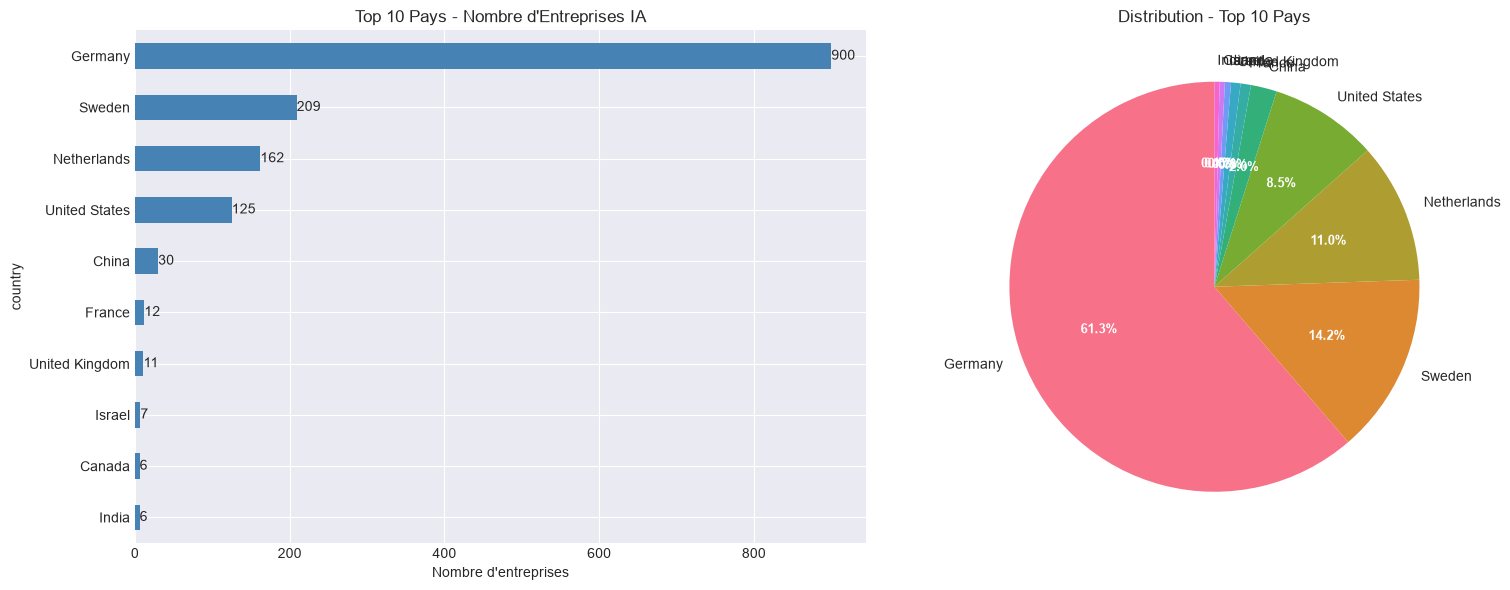

In [5]:
# Analyse par pays
country_counts = df['country'].value_counts()

print(f"\n🌍 Répartition par Pays ({len(country_counts)} pays):\n")
print(country_counts)

# Top 10 pays
top_countries = country_counts.head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1: Top 10 pays (barre horizontale)
top_countries.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Nombre d\'entreprises')
ax1.set_title('Top 10 Pays - Nombre d\'Entreprises IA')
ax1.invert_yaxis()

# Ajouter les chiffres
for i, v in enumerate(top_countries.values):
    ax1.text(v + 0.1, i, str(v), va='center')

# Graphique 2: Camembert
colors = sns.color_palette('husl', len(top_countries))
wedges, texts, autotexts = ax2.pie(top_countries.values, labels=top_countries.index, autopct='%1.1f%%',
                                     colors=colors, startangle=90)
ax2.set_title('Distribution - Top 10 Pays')

# Améliorer la lisibilité du texte
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

plt.tight_layout()
plt.show()

### Debut d'analyse
La repartition obtenue permet de visualiser les poles geographiques majeurs et d'apprecier la concentration du corpus. Une forte dominance d'un petit nombre de pays peut influencer la lecture globale des tendances IA.

## 4. Répartition par Année de Fondation

### Introduction de la section
L'analyse temporelle vise a caracteriser la dynamique de creation des entreprises IA: anciennete minimale, acceleration recente et regularite du flux de creation.

In [6]:
# Nettoyer et analyser les années
df_year = df[df['founded_year'].notna()].copy()
df_year['founded_year'] = df_year['founded_year'].astype(int)

year_counts = df_year['founded_year'].value_counts().sort_index()

print(f"\n📅 Répartition par Année de Fondation:\n")
print(year_counts.tail(20))  # Dernières 20 années

# Statistiques sur les années
print(f"\nAnnée la plus ancienne: {df_year['founded_year'].min()}")
print(f"Année la plus récente: {df_year['founded_year'].max()}")
print(f"Médiane: {df_year['founded_year'].median():.0f}")
print(f"Moyenne: {df_year['founded_year'].mean():.1f}")


📅 Répartition par Année de Fondation:

founded_year
2003     1
2004     2
2005     2
2006     1
2008     1
2009     5
2010     6
2012     8
2013     3
2014     5
2015     3
2016     6
2017     5
2018     2
2019     2
2020     4
2021     8
2022     7
2023    16
2024     4
Name: count, dtype: int64

Année la plus ancienne: 1903
Année la plus récente: 2024
Médiane: 2016
Moyenne: 2013.7


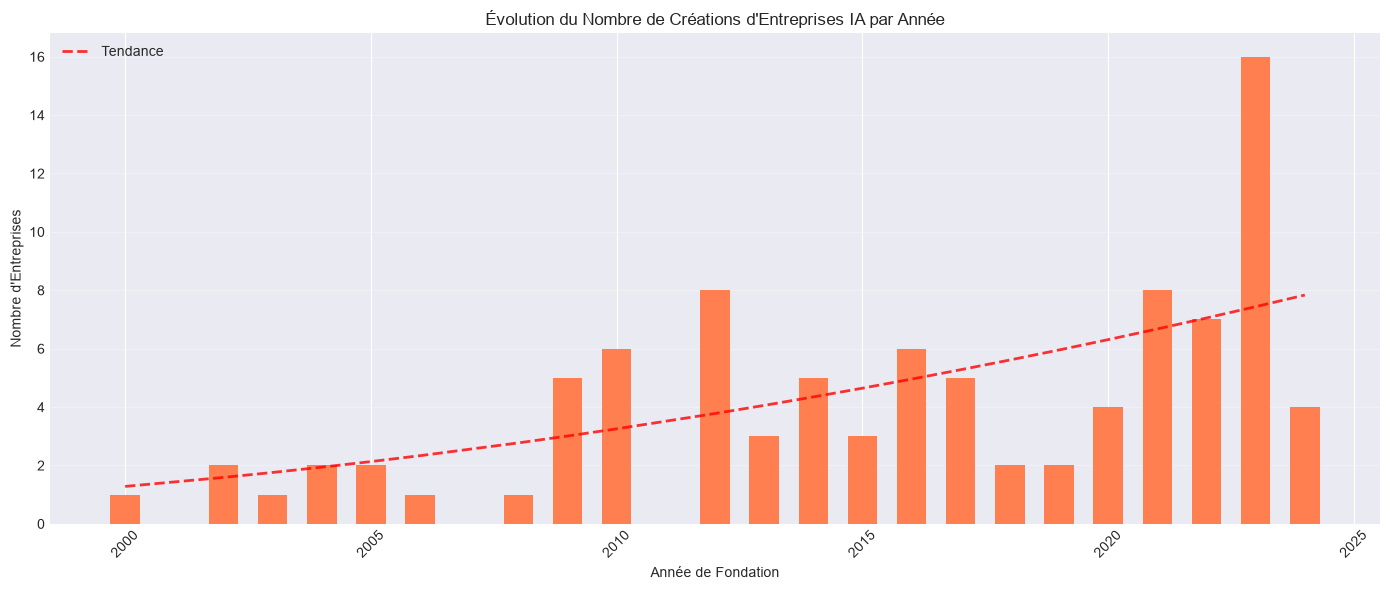

In [7]:
# Visualiser la tendance par année
fig, ax = plt.subplots(figsize=(14, 6))

# Créer des bins par période
year_counts_plot = year_counts[year_counts.index >= 2000]  # À partir de 2000

ax.bar(year_counts_plot.index, year_counts_plot.values, color='coral', width=0.6)
ax.set_xlabel('Année de Fondation')
ax.set_ylabel('Nombre d\'Entreprises')
ax.set_title('Évolution du Nombre de Créations d\'Entreprises IA par Année')
ax.grid(axis='y', alpha=0.3)

# Ajouter une tendance si assez de points
if len(year_counts_plot) >= 3:
    try:
        z = np.polyfit(year_counts_plot.index, year_counts_plot.values, 2)
        p = np.poly1d(z)
        ax.plot(year_counts_plot.index, p(year_counts_plot.index), "r--", alpha=0.8, linewidth=2, label='Tendance')
        ax.legend()
    except:
        pass

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Debut d'analyse
Les statistiques et la courbe de tendance offrent une premiere lecture du cycle de developpement de l'ecosysteme. Il convient toutefois de garder a l'esprit que seules les fiches avec annee renseignee alimentent cette vue.

## 5. Analyse Croisée: Pays × Année

### Introduction de la section
Cette analyse croisee relie geographie et temporalite pour identifier les differents rythmes de creation selon les pays les plus representes.

In [8]:
# Créer un tableau croisé dynamique
df_analysis = df[(df['country'].notna()) & (df['founded_year'].notna())].copy()
df_analysis['founded_year'] = df_analysis['founded_year'].astype(int)

# Top 8 pays pour plus de clarté
top_8_countries = df['country'].value_counts().head(8).index
df_top8 = df_analysis[df_analysis['country'].isin(top_8_countries)]

# Créer un pivot table
pivot = df_top8.pivot_table(
    values='id',
    index='founded_year',
    columns='country',
    aggfunc='count',
    fill_value=0
)

print("\n📊 Tableau Croisé - Top 8 Pays par Année:\n")
print(pivot.tail(15))


📊 Tableau Croisé - Top 8 Pays par Année:

country       China  France  Germany  Netherlands  Sweden  United Kingdom  \
founded_year                                                                
2009              2       1        0            0       0               0   
2010              0       0        0            0       0               0   
2012              2       0        0            0       0               0   
2013              1       0        0            0       0               0   
2014              3       2        0            0       0               0   
2015              2       0        0            0       0               0   
2016              0       1        0            0       0               0   
2017              0       2        0            0       0               0   
2018              0       0        0            0       0               0   
2019              0       0        0            0       0               0   
2020              0       2      

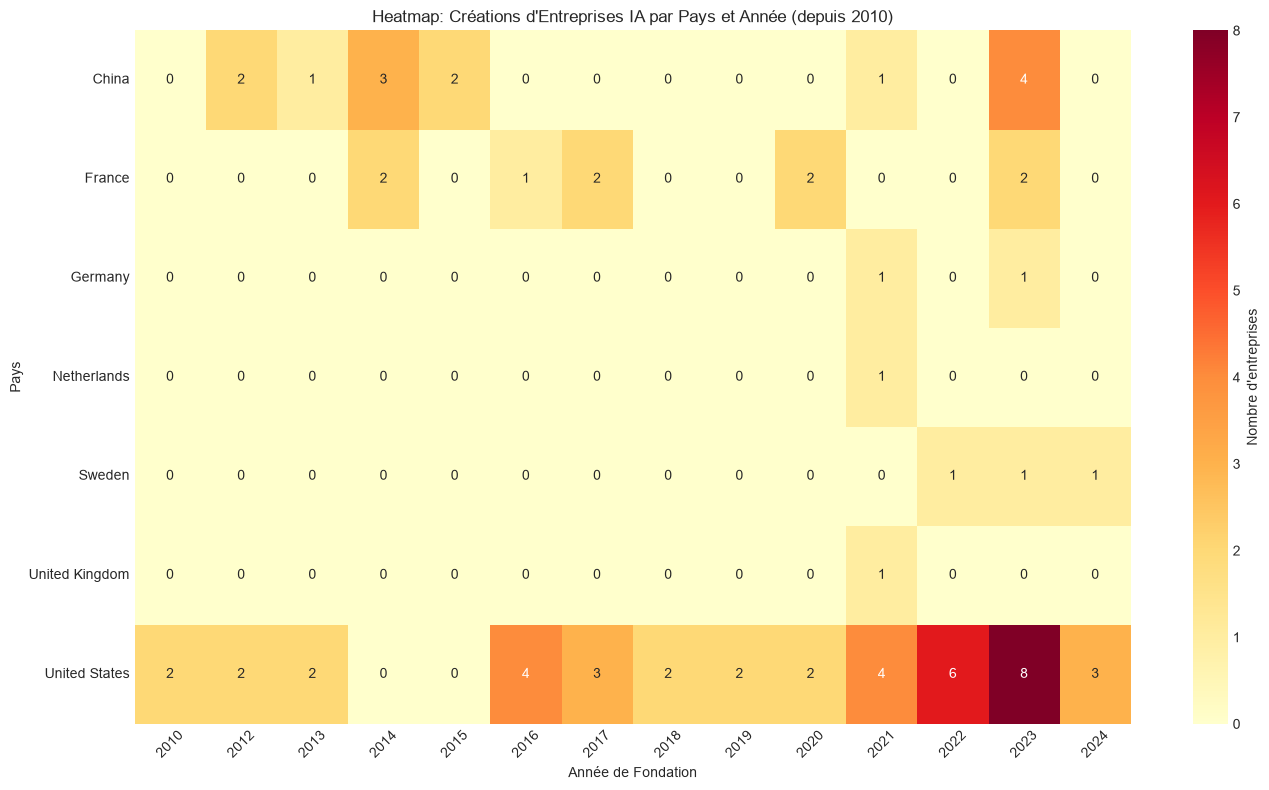

In [9]:
# Visualiser le tableau croisé avec un heatmap
if len(pivot) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    pivot_recent = pivot[pivot.index >= 2010]  # À partir de 2010
    
    if len(pivot_recent) > 0:
        sns.heatmap(pivot_recent.T, annot=True, fmt='d', cmap='YlOrRd', 
                    cbar_kws={'label': 'Nombre d\'entreprises'}, ax=ax)
        
        ax.set_xlabel('Année de Fondation')
        ax.set_ylabel('Pays')
        ax.set_title('Heatmap: Créations d\'Entreprises IA par Pays et Année (depuis 2010)')
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ Pas de données depuis 2010 pour la heatmap")
else:
    print("⚠ Pas de données croisées disponibles")

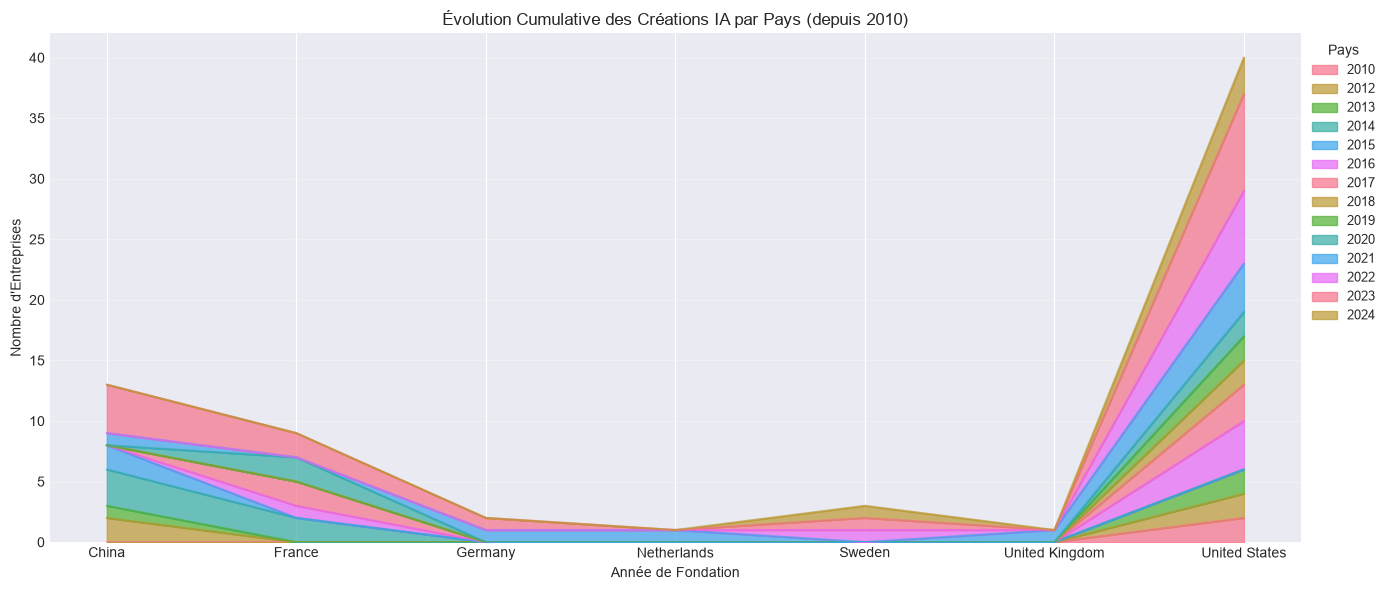

In [10]:
# Graphique en aire empilée
if len(pivot) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    pivot_recent = pivot[pivot.index >= 2010]
    
    if len(pivot_recent) > 0:
        pivot_recent_T = pivot_recent.T
        
        pivot_recent_T.plot(kind='area', stacked=True, ax=ax, alpha=0.7)
        ax.set_xlabel('Année de Fondation')
        ax.set_ylabel('Nombre d\'Entreprises')
        ax.set_title('Évolution Cumulative des Créations IA par Pays (depuis 2010)')
        ax.legend(title='Pays', loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ Pas de données depuis 2010 pour le graphique")
else:
    print("⚠ Pas de données croisées disponibles")

### Debut d'analyse
La heatmap et l'aire empilee permettent de comparer les trajectoires nationales sur une base commune. On peut ainsi distinguer les pays a croissance recente de ceux plus stables dans le temps.

## 6. Analyse par Secteur

### Introduction de la section
Cette section examine les secteurs les plus representes afin de qualifier la structure economique du corpus et d'identifier les domaines d'application IA les plus visibles.


🔧 Répartition par Secteur (207 secteurs):

sector
ICT                                                      374
Cross Industry                                           100
ICT, Operations                                           57
Cross Industry, ICT                                       52
ICT, R&D                                                  44
                                                        ... 
Transport & Mobility, Retail & E-commerce, Operations      1
Manufacturing, Energy & Utilities, Operations              1
Cross Industry, ICT, Transport & Mobility                  1
ICT, Public Sector & Aerospace, Energy & Utilities         1
Retail & E-commerce, Operations, Sales                     1
Name: count, Length: 207, dtype: int64


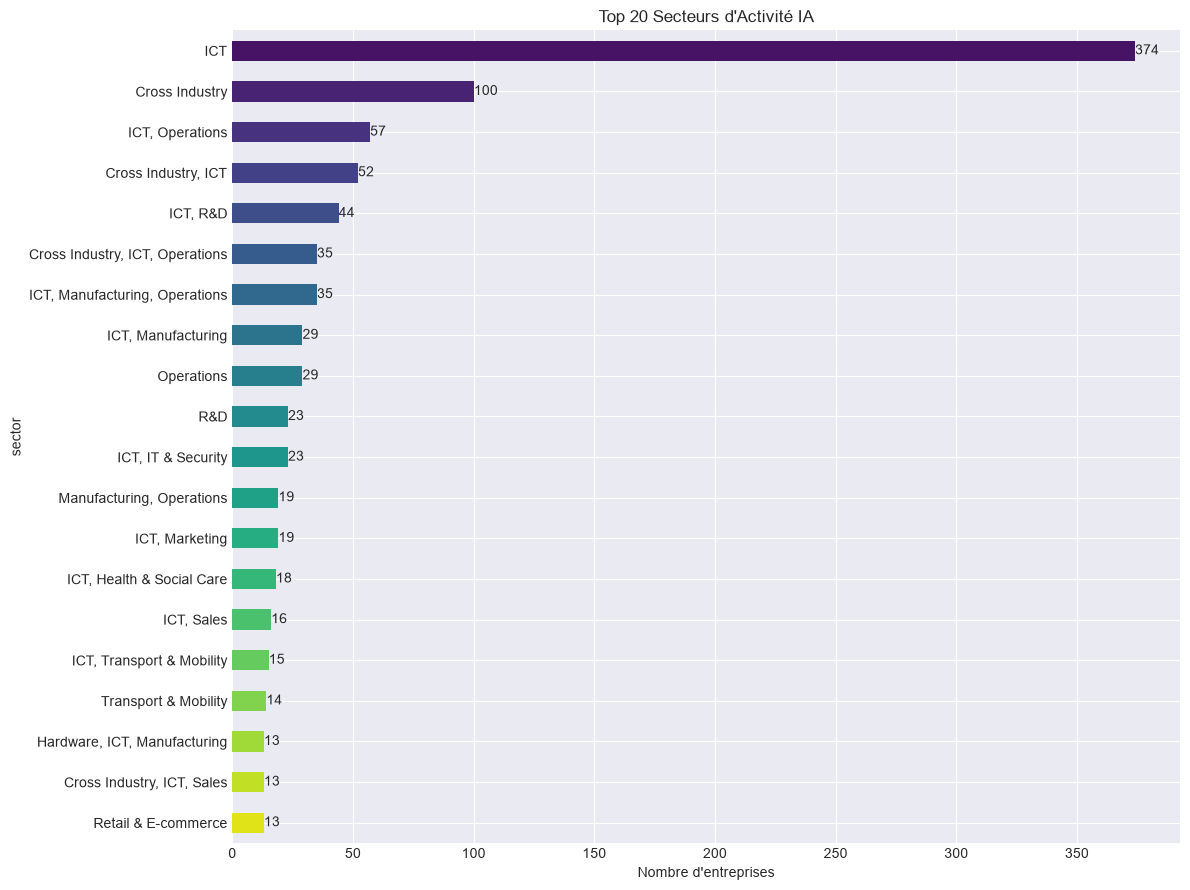

In [11]:
# Secteurs
sector_counts = df['sector'].value_counts()

print(f"\n🔧 Répartition par Secteur ({len(sector_counts)} secteurs):\n")
print(sector_counts)

# Top 20 secteurs
top_sectors = sector_counts.head(20)

fig, ax = plt.subplots(figsize=(12, 9))
top_sectors.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(top_sectors)))
ax.set_xlabel('Nombre d\'entreprises')
ax.set_title('Top 20 Secteurs d\'Activité IA')
ax.invert_yaxis()

# Ajouter les chiffres
for i, v in enumerate(top_sectors.values):
    ax.text(v + 0.1, i, str(v), va='center')

plt.tight_layout()
plt.show()

### Debut d'analyse
Le classement sectoriel met en avant les categories dominantes du portefeuille. Il sert de base pour prioriser l'enrichissement des secteurs les plus volumineux et normaliser les libelles heterogenes.

## 7. Synthèse et Insights

### Introduction de la section
La synthese consolide les indicateurs clefs (volume, geographie, temporalite, validation, completude) pour formuler des priorites d'action immediates.

In [12]:
# Résumé statistique complet (cellule autonome)
df_year_local = df[df['founded_year'].notna()].copy()
if len(df_year_local) > 0:
    df_year_local['founded_year'] = df_year_local['founded_year'].astype(int)

country_counts_local = df['country'].value_counts()
sector_counts_local = df['sector'].value_counts()

print("\n" + "="*60)
print("SYNTHÈSE - RÉSEAUX D'ACTEURS IA")
print("="*60)

print(f"\n📊 GLOBAL")
print(f"  Total d'entreprises: {len(df)}")
print(f"  Nombre de pays: {df['country'].nunique()}")
print(f"  Nombre de secteurs: {df['sector'].nunique()}")
if len(df_year_local) > 0:
    print(f"  Période couverte: {df_year_local['founded_year'].min():.0f} - {df_year_local['founded_year'].max():.0f}")
else:
    print("  Période couverte: non disponible")

print(f"\n🌍 TOP PAYS")
for i, (country, count) in enumerate(country_counts_local.head(5).items(), 1):
    pct = (count / len(df)) * 100
    print(f"  {i}. {country:15s}: {count:3d} entreprises ({pct:5.1f}%)")

print(f"\n📅 ANALYSE TEMPORELLE")
if len(df_year_local) > 0:
    print(f"  Année moyenne de création: {df_year_local['founded_year'].mean():.1f}")
    print(f"  Médiane: {df_year_local['founded_year'].median():.0f}")
    print(f"  Écart-type: {df_year_local['founded_year'].std():.1f}")
    recent_years = df_year_local[df_year_local['founded_year'] >= 2020]
    print(f"  Créations depuis 2020: {len(recent_years)} ({(len(recent_years)/len(df_year_local)*100):.1f}% du total avec année)")
else:
    print("  Données temporelles insuffisantes")

print(f"\n🔧 TOP SECTEURS")
for i, (sector, count) in enumerate(sector_counts_local.head(5).items(), 1):
    pct = (count / len(df)) * 100
    print(f"  {i}. {sector:25s}: {count:3d} entreprises ({pct:5.1f}%)")

print(f"\n💰 CAPITALISATION (format en millions)")
if 'capitalization_millions' in df.columns:
    cap_known = (df['capitalization_millions'] > 0).sum()
    print(f"  Fiches avec capitalisation renseignée (>0): {cap_known} ({(cap_known/len(df)*100):.1f}%)")
    print(f"  Somme des capitalisations (M): {df['capitalization_millions'].sum():,.1f}".replace(',', ' '))
    print(f"  Médiane (M): {df['capitalization_millions'].median():,.1f}".replace(',', ' '))

print(f"\n✅ VALIDATION (3 niveaux)")
if 'is_validated' in df.columns:
    non_validees = (df['is_validated'] == 0).sum()
    partiellement_validees = (df['is_validated'] == 1).sum()
    validees = (df['is_validated'] == 2).sum()
    print(f"  Fiches non validées: {non_validees} ({(non_validees/len(df)*100):.1f}%)")
    print(f"  Fiches validées partiellement: {partiellement_validees} ({(partiellement_validees/len(df)*100):.1f}%)")
    print(f"  Fiches validées: {validees} ({(validees/len(df)*100):.1f}%)")

print(f"\n📈 COMPLÉTUDE")
desc_count = (df['description'].notna() & (df['description'].astype(str).str.strip() != '')).sum()
web_count = (df['website'].notna() & (df['website'].astype(str).str.strip() != '')).sum()
cap_info_count = (df['capitalization_millions'] > 0).sum() if 'capitalization_millions' in df.columns else 0
print(f"  Fiches avec description: {desc_count} ({(desc_count/len(df)*100):.1f}%)")
print(f"  Fiches avec website: {web_count} ({(web_count/len(df)*100):.1f}%)")
print(f"  Fiches avec capitalization (>0): {cap_info_count} ({(cap_info_count/len(df)*100):.1f}%)")

print("\n" + "="*60)


SYNTHÈSE - RÉSEAUX D'ACTEURS IA

📊 GLOBAL
  Total d'entreprises: 1718
  Nombre de pays: 28
  Nombre de secteurs: 207
  Période couverte: 1903 - 2024

🌍 TOP PAYS
  1. Germany        : 900 entreprises ( 52.4%)
  2. Sweden         : 209 entreprises ( 12.2%)
  3. Netherlands    : 162 entreprises (  9.4%)
  4. United States  : 125 entreprises (  7.3%)
  5. China          :  30 entreprises (  1.7%)

📅 ANALYSE TEMPORELLE
  Année moyenne de création: 2013.7
  Médiane: 2016
  Écart-type: 13.9
  Créations depuis 2020: 39 (38.6% du total avec année)

🔧 TOP SECTEURS
  1. ICT                      : 374 entreprises ( 21.8%)
  2. Cross Industry           : 100 entreprises (  5.8%)
  3. ICT, Operations          :  57 entreprises (  3.3%)
  4. Cross Industry, ICT      :  52 entreprises (  3.0%)
  5. ICT, R&D                 :  44 entreprises (  2.6%)

💰 CAPITALISATION (format en millions)
  Fiches avec capitalisation renseignée (>0): 134 (7.8%)
  Somme des capitalisations (M): 12 491 721.5
  Médiane (

### Debut d'analyse
Les resultats agreges confirment une base large mais encore partiellement qualifiee. La faible part de fiches validees et la lacune financiere orientent clairement les prochains chantiers data.

## 8. Export des Résultats

### Introduction de la section
Cette section transforme les analyses en livrables CSV reutilisables pour le suivi, la restitution et les traitements complementaires hors notebook.

In [13]:
# Exporter les statistiques clés en CSV
# Créer le dossier d'export s'il n'existe pas
export_dir = './exports'
os.makedirs(export_dir, exist_ok=True)

try:
    # Normalisation défensive du niveau de validation
    if 'is_validated' in df.columns:
        df['is_validated'] = pd.to_numeric(df['is_validated'], errors='coerce').fillna(0).astype(int)

    # Export 1: Résumé par pays
    country_summary = df.groupby('country').agg(
        nombre_entreprises=('id', 'count'),
        annee_creation_min=('founded_year', 'min'),
        annee_creation_max=('founded_year', 'max'),
        annee_creation_moyenne=('founded_year', 'mean'),
        capitalisation_millions_totale=('capitalization_millions', 'sum'),
        capitalisation_millions_moyenne=('capitalization_millions', 'mean'),
        nombre_non_validees=('is_validated', lambda s: (s == 0).sum()),
        nombre_validees_partiellement=('is_validated', lambda s: (s == 1).sum()),
        nombre_validees=('is_validated', lambda s: (s == 2).sum())
    ).round(1)
    country_summary['taux_validees_partiellement_pct'] = (
        country_summary['nombre_validees_partiellement'] / country_summary['nombre_entreprises'] * 100
    ).round(1)
    country_summary['taux_validees_pct'] = (
        country_summary['nombre_validees'] / country_summary['nombre_entreprises'] * 100
    ).round(1)
    country_summary = country_summary.sort_values('nombre_entreprises', ascending=False)
    country_summary.to_csv(f'{export_dir}/statistiques_par_pays.csv')
    print(f"✓ Exporté: statistiques_par_pays.csv")

    # Export 2: Résumé par secteur
    sector_summary = df.groupby('sector').agg(
        nombre_entreprises=('id', 'count'),
        annee_creation_min=('founded_year', 'min'),
        annee_creation_max=('founded_year', 'max'),
        annee_creation_moyenne=('founded_year', 'mean'),
        capitalisation_millions_totale=('capitalization_millions', 'sum'),
        capitalisation_millions_moyenne=('capitalization_millions', 'mean'),
        nombre_non_validees=('is_validated', lambda s: (s == 0).sum()),
        nombre_validees_partiellement=('is_validated', lambda s: (s == 1).sum()),
        nombre_validees=('is_validated', lambda s: (s == 2).sum())
    ).round(1)
    sector_summary['taux_validees_partiellement_pct'] = (
        sector_summary['nombre_validees_partiellement'] / sector_summary['nombre_entreprises'] * 100
    ).round(1)
    sector_summary['taux_validees_pct'] = (
        sector_summary['nombre_validees'] / sector_summary['nombre_entreprises'] * 100
    ).round(1)
    sector_summary = sector_summary.sort_values('nombre_entreprises', ascending=False)
    sector_summary.to_csv(f'{export_dir}/statistiques_par_secteur.csv')
    print(f"✓ Exporté: statistiques_par_secteur.csv")

    # Export 3: Données brutes enrichies
    export_cols = [
        'id', 'name', 'sector', 'country', 'founded_year',
        'is_validated', 'description', 'website',
        'capitalization', 'capitalization_millions',
        'headquarter_city', 'main_investors', 'funds_raised'
    ]
    export_cols = [c for c in export_cols if c in df.columns]
    df_export = df[export_cols].copy()
    df_export.to_csv(f'{export_dir}/donnees_completes.csv', index=False)
    print(f"✓ Exporté: donnees_completes.csv")

    print(f"\n✓ Tous les exports disponibles dans: {export_dir}/")
except Exception as e:
    print(f"✗ Erreur lors de l'export: {e}")

✓ Exporté: statistiques_par_pays.csv
✓ Exporté: statistiques_par_secteur.csv
✓ Exporté: donnees_completes.csv

✓ Tous les exports disponibles dans: ./exports/


### Debut d'analyse
Les exports produisent une base de diffusion standardisee pour le pilotage. Ils permettent de suivre l'evolution des KPI dans le temps et d'alimenter des restitutions externes sans rejouer toute l'analyse.